In [1]:
# Cài đặt model
#!pip install statsmodels
#!pip install openpyxl

## 1. Khởi tạo môi trường & import thư viện

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import jarque_bera, shapiro
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
import statsmodels.api as sm

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

def hline(text=""):
    print("-" * 80)
    if text:
        print("📌 KẾT LUẬN / DIỄN GIẢI:")
        print(text)
    print("-" * 80)

## 2. Nạp dữ liệu gốc & Tiền xử lý dữ liệu ( Xoá dòng trùng )

In [8]:
file_path = "FINAL DATASET.xlsx"
df_raw = pd.read_excel(file_path)

df = df_raw.copy()
df.columns = [c.lower() for c in df.columns]

df["time"] = pd.to_datetime(df["time"])

# Lọc từ ngày 2021-03-24
df = df[df["time"] >= "2021-03-24"].copy()

# ✨ Loại bỏ toàn bộ dữ liệu của mã ROS
df = df[df["symbol"] != "ROS"].copy()

before = df.shape[0]
df = df.drop_duplicates(subset=["time", "symbol"], keep="first")
after = df.shape[0]

print(df.head())
print("Kích thước sau lọc ngày & xoá trùng:", df.shape)
print("Số dòng trùng đã loại:", before - after)

print("\nSố mã cổ phiếu:", df["symbol"].nunique())
print("Khoảng thời gian:", df["time"].min(), "→", df["time"].max())

hline(
    "- Đã giới hạn dữ liệu kể từ ngày 24/03/2021 để tránh các phiên có dữ liệu thiếu cho một số mã.\n"
    "- Đã loại bỏ mã chứng khoán ROS vì bị huỷ niêm yết và thiếu thời gian quá nhiều.\n"
    "- Đã loại bỏ các dòng trùng lặp theo (time, symbol), đảm bảo mỗi mã chỉ có một quan sát duy nhất mỗi ngày.\n"
    "- Dataset sau xử lý có cấu trúc sạch, phù hợp để pivot sang dạng wide và phân tích sâu hơn."
)

        time   open  close   volume symbol industry     order  usdvnd  usdreturn
0 2021-03-24  12.16  12.18  9941600    ACB    Banks  0.035794   23.08   0.000173
2 2021-03-25  12.19  12.02  8322000    ACB    Banks -0.065665  23.084   0.000000
4 2021-03-26  12.01  12.18  7931700    ACB    Banks  0.024183  23.084  -0.000607
6 2021-03-29  12.34  12.38  6981300    ACB    Banks -0.005518   23.07   0.000000
8 2021-03-30  12.42  12.49  8053200    ACB    Banks -0.152632   23.07   0.000173
Kích thước sau lọc ngày & xoá trùng: (47475, 9)
Số dòng trùng đã loại: 11224

Số mã cổ phiếu: 41
Khoảng thời gian: 2021-03-24 00:00:00 → 2025-11-10 00:00:00
--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Đã giới hạn dữ liệu kể từ ngày 24/03/2021 để tránh các phiên có dữ liệu thiếu cho một số mã.
- Đã loại bỏ mã chứng khoán ROS vì bị huỷ niêm yết và thiếu thời gian quá nhiều.
- Đã loại bỏ các dòng trùng lặp theo (time, symbol), đảm bảo mỗi mã chỉ có m

In [9]:
prices = df.pivot(index="time", columns="symbol", values="close")
log_returns = np.log(prices).diff()   # diff() = log(return) luôn, nhanh hơn
log_returns = log_returns.dropna(how="all")

In [10]:
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# Cột sử dụng
DATE_COL    = "time"
SYMBOL_COL  = "symbol"
VOLUME_COL  = "volume"
USDRET_COL  = "usdreturn"
ORDER_COL   = "order"

TOP_N_STOCKS = 20
EXCLUDE = ["VNINDEX", "VN30", "VN30INDEX", "ROS"]

# Lọc bỏ index & ROS trước khi xếp hạng thanh khoản
df_liq = df[~df[SYMBOL_COL].isin(EXCLUDE)].copy()

liq_stats = (
    df_liq.groupby(SYMBOL_COL)[VOLUME_COL]
          .mean()
          .sort_values(ascending=False)
)

top_symbols = liq_stats.head(TOP_N_STOCKS).index.tolist()

print(f"TOP {TOP_N_STOCKS} mã theo thanh khoản (đã loại VNINDEX/VN30/ROS):")
print(top_symbols)
print("Số mã được chọn:", len(top_symbols))

TOP 20 mã theo thanh khoản (đã loại VNINDEX/VN30/ROS):
['SHB', 'HPG', 'SSI', 'VPB', 'STB', 'MBB', 'NVL', 'TCB', 'TPB', 'PDR', 'TCH', 'CTG', 'ACB', 'HDB', 'LPB', 'VRE', 'VHM', 'EIB', 'MWG', 'VIB']
Số mã được chọn: 20


In [11]:
# Lọc log_returns chỉ giữ 20 mã đã chọn
ret20 = log_returns[top_symbols].copy()

# Giới hạn cùng thời gian với df nếu muốn chắc chắn
ret20 = ret20[ret20.index >= pd.to_datetime("2021-03-24")]

print("Shape ret20 trước dropna:", ret20.shape)

# Bỏ những ngày thiếu bất kỳ mã nào
ret20 = ret20.dropna(how="any")

print("Shape ret20 sau dropna:", ret20.shape)
print("Các mã trong ret20:", list(ret20.columns))

Shape ret20 trước dropna: (1157, 20)
Shape ret20 sau dropna: (1153, 20)
Các mã trong ret20: ['SHB', 'HPG', 'SSI', 'VPB', 'STB', 'MBB', 'NVL', 'TCB', 'TPB', 'PDR', 'TCH', 'CTG', 'ACB', 'HDB', 'LPB', 'VRE', 'VHM', 'EIB', 'MWG', 'VIB']


In [12]:
# usdreturn mỗi ngày (giả sử chung cho toàn thị trường)
usd_series = (
    df.groupby(DATE_COL)[USDRET_COL]
      .first()
      .reindex(ret20.index)
)

# order_avg = trung bình order của 20 mã trong ngày đó
order_series = (
    df[df[SYMBOL_COL].isin(top_symbols)]
      .groupby(DATE_COL)[ORDER_COL]
      .mean()
      .reindex(ret20.index)
)

# Dataset cuối cùng cho VAR
data_for_var = ret20.copy()
data_for_var["usdreturn"] = usd_series
data_for_var["order_avg"] = order_series

data_for_var = data_for_var.dropna(how="any")

print("Final data_for_var shape:", data_for_var.shape)
print("Các biến trong VAR:", data_for_var.columns.tolist())

Final data_for_var shape: (1153, 22)
Các biến trong VAR: ['SHB', 'HPG', 'SSI', 'VPB', 'STB', 'MBB', 'NVL', 'TCB', 'TPB', 'PDR', 'TCH', 'CTG', 'ACB', 'HDB', 'LPB', 'VRE', 'VHM', 'EIB', 'MWG', 'VIB', 'usdreturn', 'order_avg']


In [13]:
def adf_test(series, name=""):
    s = series.dropna()
    stat, pval = adfuller(s)[0:2]
    print(f"ADF – {name:12s}: stat = {stat:8.3f}, p-value = {pval:8.4f}")

print("=== ADF test cho tất cả biến trong data_for_var ===")
for col in data_for_var.columns:
    adf_test(data_for_var[col], name=col)

=== ADF test cho tất cả biến trong data_for_var ===
ADF – SHB         : stat =  -30.163, p-value =   0.0000
ADF – HPG         : stat =  -31.820, p-value =   0.0000
ADF – SSI         : stat =  -18.690, p-value =   0.0000
ADF – VPB         : stat =   -6.478, p-value =   0.0000
ADF – STB         : stat =  -26.065, p-value =   0.0000
ADF – MBB         : stat =  -24.733, p-value =   0.0000
ADF – NVL         : stat =   -7.882, p-value =   0.0000
ADF – TCB         : stat =  -31.703, p-value =   0.0000
ADF – TPB         : stat =  -11.006, p-value =   0.0000
ADF – PDR         : stat =  -12.247, p-value =   0.0000
ADF – TCH         : stat =  -31.932, p-value =   0.0000
ADF – CTG         : stat =  -25.554, p-value =   0.0000
ADF – ACB         : stat =  -20.830, p-value =   0.0000
ADF – HDB         : stat =  -34.349, p-value =   0.0000
ADF – LPB         : stat =  -24.371, p-value =   0.0000
ADF – VRE         : stat =  -25.176, p-value =   0.0000
ADF – VHM         : stat =  -30.067, p-value =   0.0

In [14]:
from statsmodels.tsa.api import VAR

model = VAR(data_for_var)

# Tham khảo lựa chọn lag (AIC/BIC/HQIC/FPE)
lag_order_res = model.select_order(maxlags=5)
print(lag_order_res.summary())

# Dù kết quả thế nào, ta dùng VAR(1) để có ý nghĩa Granger (chuẩn tài chính)
p_opt = 1
print("Lag VAR sử dụng cho Granger:", p_opt)

var_res = model.fit(p_opt)
print(var_res.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -180.3     -180.2*   4.762e-79     -180.3*
1     -180.6*      -178.4  3.765e-79*      -179.7
2      -180.3      -176.0   4.842e-79      -178.7
3      -180.1      -173.6   6.375e-79      -177.6
4      -179.8      -171.2   8.452e-79      -176.5
5      -179.5      -168.8   1.120e-78      -175.4
-------------------------------------------------
Lag VAR sử dụng cho Granger: 1
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 20, Nov, 2025
Time:                     07:55:32
--------------------------------------------------------------------
No. of Equations:         22.0000    BIC:                   -178.316
Nobs:                     1152.00    HQIC:                  -179.697
Log likelihood:           68532.1    FPE:                3.93609e-79
AIC:              

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [15]:
ALPHA = 0.05           # mức ý nghĩa
stocks = top_symbols   # node trong network

adj_matrix  = pd.DataFrame(0, index=stocks, columns=stocks, dtype=int)
pval_matrix = pd.DataFrame(np.nan, index=stocks, columns=stocks)

for cause in stocks:
    for effect in stocks:
        if cause == effect:
            continue

        # Conditional Granger: cause -> effect, conditional on all other variables
        test_res = var_res.test_causality(
            caused=effect,
            causing=[cause],
            kind="f"
        )
        pval = test_res.pvalue
        pval_matrix.loc[cause, effect] = pval

        if pval < ALPHA:
            adj_matrix.loc[cause, effect] = 1

print("CGCI adjacency matrix (1 = có quan hệ nhân quả có ý nghĩa):")
print(adj_matrix)

adj_matrix.to_csv("cgci_adjacency_matrix.csv")
pval_matrix.to_csv("cgci_pvalues_matrix.csv")

print("Đã lưu cgci_adjacency_matrix.csv và cgci_pvalues_matrix.csv")

CGCI adjacency matrix (1 = có quan hệ nhân quả có ý nghĩa):
     SHB  HPG  SSI  VPB  STB  MBB  NVL  TCB  TPB  PDR  TCH  CTG  ACB  HDB  LPB  VRE  VHM  EIB  MWG  VIB
SHB    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    1    0    0    0
HPG    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0
SSI    0    0    0    1    0    1    0    0    1    1    1    1    0    0    0    1    0    0    0    0
VPB    0    0    0    0    0    0    0    0    0    0    0    0    0    0    1    0    0    0    0    0
STB    0    0    0    1    0    1    0    0    0    1    0    0    0    0    0    1    0    0    1    0
MBB    0    0    0    1    0    0    0    0    0    1    0    0    0    0    0    0    0    1    1    0
NVL    0    0    0    0    0    0    0    1    0    1    0    0    1    0    0    0    1    0    0    0
TCB    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0
TPB 

In [16]:
# out_degree: số cạnh i -> j (hàng)
out_deg = adj_matrix.sum(axis=1)

# in_degree: số cạnh k -> i (cột)
in_deg  = adj_matrix.sum(axis=0)

deg_df = pd.DataFrame({
    "out_degree": out_deg,
    "in_degree": in_deg
})
deg_df["net_degree"] = deg_df["out_degree"] - deg_df["in_degree"]

print("Bảng độ trung tâm (degree) của từng cổ phiếu:")
print(deg_df.sort_values("out_degree", ascending=False))

Bảng độ trung tâm (degree) của từng cổ phiếu:
     out_degree  in_degree  net_degree
PDR          10          5           5
SSI           7          3           4
TCH           6          3           3
STB           5          2           3
CTG           4          2           2
NVL           4          2           2
MBB           4          4           0
EIB           3          1           2
MWG           2          3          -1
VRE           2          5          -3
SHB           1          1           0
VPB           1          5          -4
VHM           1          3          -2
HDB           1          0           1
LPB           1          3          -2
ACB           1          2          -1
VIB           1          2          -1
HPG           0          4          -4
TPB           0          2          -2
TCB           0          2          -2


In [17]:
transmitters = deg_df[deg_df["net_degree"] > 0].index.tolist()
neutrals     = deg_df[deg_df["net_degree"] == 0].index.tolist()
receivers    = deg_df[deg_df["net_degree"] < 0].index.tolist()

print("Transmitters (shock emitters):", transmitters)
print("Neutrals:", neutrals)
print("Receivers (shock absorbers):", receivers)

Transmitters (shock emitters): ['SSI', 'STB', 'NVL', 'PDR', 'TCH', 'CTG', 'HDB', 'EIB']
Neutrals: ['SHB', 'MBB']
Receivers (shock absorbers): ['HPG', 'VPB', 'TCB', 'TPB', 'ACB', 'LPB', 'VRE', 'VHM', 'MWG', 'VIB']


Số node: 20
Số cạnh: 54


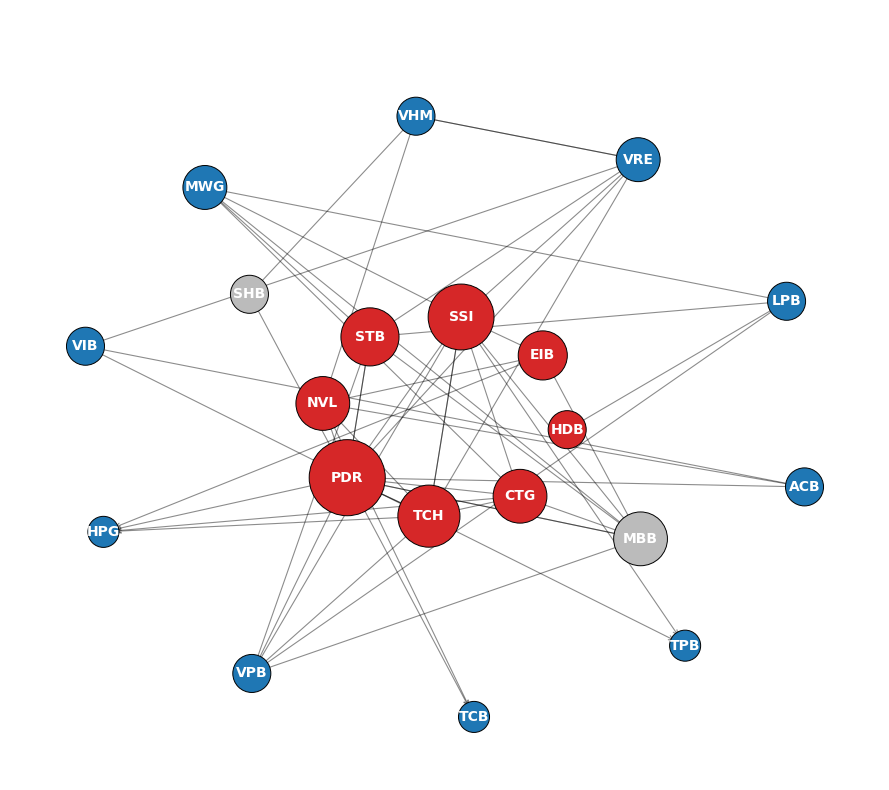

In [18]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

G = nx.DiGraph()

# Thêm node
for n in adj_matrix.index:
    G.add_node(n)

# Thêm cạnh theo CGCI
for i in adj_matrix.index:
    for j in adj_matrix.columns:
        if adj_matrix.loc[i, j] == 1:
            G.add_edge(i, j)

print("Số node:", G.number_of_nodes())
print("Số cạnh:", G.number_of_edges())

# Node size theo out_degree
sizes = [500 + 250 * deg_df.loc[n, "out_degree"] for n in G.nodes()]

# Node color theo role
colors = []
for n in G.nodes():
    if n in transmitters:
        colors.append("#d62728")  # đỏ
    elif n in receivers:
        colors.append("#1f77b4")  # xanh
    else:
        colors.append("#bbbbbb")  # xám

# Shell layout: inner=transmitters, middle=neutrals, outer=receivers
shells = []
if transmitters:
    shells.append(transmitters)
if neutrals:
    shells.append(neutrals)
if receivers:
    shells.append(receivers)

pos = nx.shell_layout(G, nlist=shells)

# Rotate graph nhẹ cho đẹp
angle = np.pi / 8
rot_pos = {}
for k, (x, y) in pos.items():
    rot_pos[k] = (x*np.cos(angle) - y*np.sin(angle),
                  x*np.sin(angle) + y*np.cos(angle))

plt.figure(figsize=(9, 8))

nx.draw_networkx_edges(
    G, rot_pos,
    arrowstyle="->",
    arrowsize=8,
    width=0.8,
    alpha=0.45
)

nx.draw_networkx_nodes(
    G, rot_pos,
    node_size=sizes,
    node_color=colors,
    edgecolors="black",
    linewidths=0.7
)

nx.draw_networkx_labels(
    G, rot_pos,
    font_size=10,
    font_weight="bold",
    font_color="white"   # >>> CHỮ TRẮNG <<<
)

plt.title("CGCI Network – Top 20 VN30 Stocks\nShell layout: inner=transmitters, outer=receivers",
          fontsize=13, color="white")

plt.axis("off")
plt.tight_layout()
plt.show()

# PCMIC

In [19]:
# Run these commands to reinstall tigramite
#!pip install git+https://github.com/jakobrunge/tigramite.git
#!pip install numba

In [20]:
import numpy as np
from tigramite import data_processing as pp

# Nếu bạn còn biến ret20 từ phần CGCI:
#   ret20: log-return của 20 mã, đã giới hạn thời gian & dropna
# Thì dùng lại luôn cho chắc:

X_df = ret20.copy()

# Nếu không còn ret20, bạn có thể tạo lại như sau:
# X_df = (
#     log_returns[top_symbols]
#     .loc["2021-03-24":"2025-11-10"]
#     .dropna(how="any")
# )

print("PCMCI input shape:", X_df.shape)
print("Columns:", X_df.columns.tolist())

# Chuyển sang numpy cho tigramite
X = X_df.values
T, N = X.shape
var_names = list(X_df.columns)

dataframe_tig = pp.DataFrame(
    X,
    datatime=np.arange(T),
    var_names=var_names
)

print("dataframe_tig READY with T =", T, ", N =", N)

PCMCI input shape: (1153, 20)
Columns: ['SHB', 'HPG', 'SSI', 'VPB', 'STB', 'MBB', 'NVL', 'TCB', 'TPB', 'PDR', 'TCH', 'CTG', 'ACB', 'HDB', 'LPB', 'VRE', 'VHM', 'EIB', 'MWG', 'VIB']
dataframe_tig READY with T = 1153 , N = 20


In [21]:
import pandas as pd
import numpy as np

# Giả định top_symbols đã tồn tại từ phần CGCI:
# print(top_symbols)

# Lấy log-return cho đúng 20 mã
ret20 = log_returns[top_symbols].copy()

# Giới hạn thời gian giống CGCI: 2021-03-24 -> 2025-11-10
ret20 = ret20.loc["2021-03-24":"2025-11-10"]

# Bỏ các ngày bị thiếu bất kỳ mã nào
ret20 = ret20.dropna(how="any")

print("ret20 shape:", ret20.shape)
print("Các mã trong ret20:", ret20.columns.tolist())

ret20 shape: (1153, 20)
Các mã trong ret20: ['SHB', 'HPG', 'SSI', 'VPB', 'STB', 'MBB', 'NVL', 'TCB', 'TPB', 'PDR', 'TCH', 'CTG', 'ACB', 'HDB', 'LPB', 'VRE', 'VHM', 'EIB', 'MWG', 'VIB']


In [22]:
from tigramite import data_processing as pp

# Chuyển ret20 sang numpy: (T × N)
X = ret20.values
T, N = X.shape
var_names = list(ret20.columns)

print("PCMCI input: T =", T, "| N =", N)
print("Biến:", var_names)

# DataFrame đặc biệt của tigramite
dataframe_tig = pp.DataFrame(
    X,
    datatime=np.arange(T),   # chỉ cần chỉ số thời gian 0..T-1
    var_names=var_names
)

print("dataframe_tig READY")

PCMCI input: T = 1153 | N = 20
Biến: ['SHB', 'HPG', 'SSI', 'VPB', 'STB', 'MBB', 'NVL', 'TCB', 'TPB', 'PDR', 'TCH', 'CTG', 'ACB', 'HDB', 'LPB', 'VRE', 'VHM', 'EIB', 'MWG', 'VIB']
dataframe_tig READY


In [23]:
# ret20 = log-return 20 mã mà bạn có từ phần CGCI
# Nếu bạn chưa có ret20, tạo lại như sau:

X_df = (
    log_returns[top_symbols]          # dùng đúng 20 mã đã loại VNINDEX, VN30, ROS
    .loc["2021-03-24":"2025-11-10"]   # đúng khoảng thời gian yêu cầu
    .dropna(how="any")
)

print("Shape:", X_df.shape)
print("Symbols:", X_df.columns.tolist())

Shape: (1153, 20)
Symbols: ['SHB', 'HPG', 'SSI', 'VPB', 'STB', 'MBB', 'NVL', 'TCB', 'TPB', 'PDR', 'TCH', 'CTG', 'ACB', 'HDB', 'LPB', 'VRE', 'VHM', 'EIB', 'MWG', 'VIB']


In [24]:
from tigramite import data_processing as pp
import numpy as np

X = X_df.values
T, N = X.shape
var_names = list(X_df.columns)

dataframe_tig = pp.DataFrame(
    X,
    datatime=np.arange(T),
    var_names=var_names
)

print("dataframe_tig READY: T =", T, ", N =", N)

dataframe_tig READY: T = 1153 , N = 20


In [ ]:
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.pcmci import PCMCI

# nonlinear independence test – dùng shuffle_test thay analytic
cmi_knn = CMIknn(
    significance='shuffle_test',   # << Ở ĐÂY LÀ KHÁC
    knn=5,
    shuffle_neighbors=3
)

pcmci_nl = PCMCI(
    dataframe=dataframe_tig,
    cond_ind_test=cmi_knn
)

results = pcmci_nl.run_pcmci(
    tau_max=1,
    pc_alpha=0.05
)

val_matrix = results["val_matrix"]
p_matrix   = results["p_matrix"]

print("val_matrix:", val_matrix.shape)
print("p_matrix :", p_matrix.shape)

In [ ]:
alpha = 0.05

adj_pcmci  = pd.DataFrame(0, index=var_names, columns=var_names)
pval_pcmci = pd.DataFrame(np.nan, index=var_names, columns=var_names)

for i, cause in enumerate(var_names):
    for j, effect in enumerate(var_names):
        if i == j:
            continue
        pval = p_matrix[i, j, 1]      # lag 1
        pval_pcmci.loc[cause, effect] = pval
        if pval < alpha:
            adj_pcmci.loc[cause, effect] = 1

adj_pcmci.to_csv("pcmci_adjacency_matrix.csv")
pval_pcmci.to_csv("pcmci_pvalues_matrix.csv")

print(adj_pcmci)

In [ ]:
out_deg = adj_pcmci.sum(axis=1)
in_deg  = adj_pcmci.sum(axis=0)

deg_pcmci = pd.DataFrame({
    "out_degree": out_deg,
    "in_degree": in_deg
})
deg_pcmci["net_degree"] = deg_pcmci["out_degree"] - deg_pcmci["in_degree"]

print(deg_pcmci.sort_values("out_degree", ascending=False))

transmitters = deg_pcmci[deg_pcmci["net_degree"] > 0].index.tolist()
neutrals     = deg_pcmci[deg_pcmci["net_degree"] == 0].index.tolist()
receivers    = deg_pcmci[deg_pcmci["net_degree"] < 0].index.tolist()

print("Transmitters:", transmitters)
print("Neutrals:", neutrals)
print("Receivers:", receivers)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

plt.style.use("dark_background")

G = nx.DiGraph()

# add nodes
for n in adj_pcmci.index:
    G.add_node(n)

# add edges
for i in adj_pcmci.index:
    for j in adj_pcmci.columns:
        if adj_pcmci.loc[i, j] == 1:
            G.add_edge(i, j)

sizes = [500 + 250 * deg_pcmci.loc[n, "out_degree"] for n in G.nodes()]

colors = []
for n in G.nodes():
    if n in transmitters:
        colors.append("#d62728")
    elif n in receivers:
        colors.append("#1f77b4")
    else:
        colors.append("#bbbbbb")

shells = []
if transmitters: shells.append(transmitters)
if neutrals:     shells.append(neutrals)
if receivers:    shells.append(receivers)

pos = nx.shell_layout(G, nlist=shells)

plt.figure(figsize=(9,8))

nx.draw_networkx_edges(G, pos, arrowstyle="->", alpha=0.45)
nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors, edgecolors="black")
nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold")

plt.title("Nonlinear Causal Network – PCMCI (CMIknn)", color="white")
plt.axis("off")
plt.tight_layout()
plt.show()